In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
import os
load_dotenv()

True

In [3]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    google_api_key=os.environ.get("GEMINI_API_KEY")
)

In [4]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [5]:
def generate_joke(state: JokeState):
    prompt = f"Generate a joke about {state['topic']}."
    response = llm.invoke(prompt).content

    return {"joke": response}

In [6]:
def generate_explanation(state: JokeState):
    prompt = f"Explain the joke about {state['topic']}."
    response = llm.invoke(prompt).content

    return {"explanation": response}

In [7]:
graph = StateGraph(JokeState)

graph.add_node("generate_joke", generate_joke)
graph.add_node("generate_explanation", generate_explanation)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "generate_explanation")
graph.add_edge("generate_explanation", END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

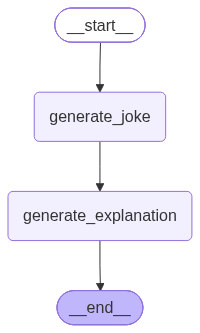

In [8]:
workflow

In [9]:
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({"topic": "Football"}, config=config1)

{'topic': 'Football',
 'joke': 'Why did the football coach go to the bank?\n\nTo get his quarter-back!',
 'explanation': 'The most common and fundamental joke about "football" hinges on the **two different sports** that share the name, particularly the distinction between **American Football** and **Soccer** (which is called \'football\' in most of the rest of the world).\n\nHere\'s the breakdown:\n\n1.  **The Core Confusion:**\n    *   In **North America (primarily the US and Canada)**, "football" refers to the sport played with an oval-shaped ball, helmets, pads, and a lot of throwing and carrying.\n    *   In **most of the rest of the world (Europe, South America, Africa, Asia, Australia)**, "football" refers to what North Americans call "soccer," played with a round ball, primarily using feet to kick it.\n\n2.  **The Irony/Punchline:**\n    *   **American Football:** The irony is that players primarily use their *hands* to throw, catch, and carry the oval-shaped ball. The *foot* is

In [10]:
# see the state
workflow.get_state(config1)

StateSnapshot(values={'topic': 'Football', 'joke': 'Why did the football coach go to the bank?\n\nTo get his quarter-back!', 'explanation': 'The most common and fundamental joke about "football" hinges on the **two different sports** that share the name, particularly the distinction between **American Football** and **Soccer** (which is called \'football\' in most of the rest of the world).\n\nHere\'s the breakdown:\n\n1.  **The Core Confusion:**\n    *   In **North America (primarily the US and Canada)**, "football" refers to the sport played with an oval-shaped ball, helmets, pads, and a lot of throwing and carrying.\n    *   In **most of the rest of the world (Europe, South America, Africa, Asia, Australia)**, "football" refers to what North Americans call "soccer," played with a round ball, primarily using feet to kick it.\n\n2.  **The Irony/Punchline:**\n    *   **American Football:** The irony is that players primarily use their *hands* to throw, catch, and carry the oval-shaped 

In [11]:
# all intermediate states
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Football', 'joke': 'Why did the football coach go to the bank?\n\nTo get his quarter-back!', 'explanation': 'The most common and fundamental joke about "football" hinges on the **two different sports** that share the name, particularly the distinction between **American Football** and **Soccer** (which is called \'football\' in most of the rest of the world).\n\nHere\'s the breakdown:\n\n1.  **The Core Confusion:**\n    *   In **North America (primarily the US and Canada)**, "football" refers to the sport played with an oval-shaped ball, helmets, pads, and a lot of throwing and carrying.\n    *   In **most of the rest of the world (Europe, South America, Africa, Asia, Australia)**, "football" refers to what North Americans call "soccer," played with a round ball, primarily using feet to kick it.\n\n2.  **The Irony/Punchline:**\n    *   **American Football:** The irony is that players primarily use their *hands* to throw, catch, and carry the oval-shaped

In [12]:
#another example
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({"topic": "Cricket"}, config=config2)

{'topic': 'Cricket',
 'joke': 'Why did the cricket team bring a ladder to the game?\nBecause they heard the pitch was high!',
 'explanation': 'The most common joke about Cricket, especially for those unfamiliar with the sport (or even for fans who can laugh at its quirks), revolves around its **length, complexity, and the possibility of a draw (no winner).**\n\nHere\'s the classic version of the joke, or variations of it:\n\n**"Cricket is a game invented by the English to make other sports look interesting."**\n\nOr, more elaborately:\n\n**"Cricket is a game where you have two teams, one out in the field, one in the pavilion, and two umpires, and it goes on for five days, and then it rains, and nobody wins."**\n\nLet\'s break down why this is funny to many:\n\n1.  **"It goes on for five days..."**\n    *   **The Reality:** Test cricket, the longest and most traditional form of the game, is indeed scheduled to last up to five days. Each day has multiple sessions of play.\n    *   **The 

In [13]:
# see the state
workflow.get_state(config2)

StateSnapshot(values={'topic': 'Cricket', 'joke': 'Why did the cricket team bring a ladder to the game?\nBecause they heard the pitch was high!', 'explanation': 'The most common joke about Cricket, especially for those unfamiliar with the sport (or even for fans who can laugh at its quirks), revolves around its **length, complexity, and the possibility of a draw (no winner).**\n\nHere\'s the classic version of the joke, or variations of it:\n\n**"Cricket is a game invented by the English to make other sports look interesting."**\n\nOr, more elaborately:\n\n**"Cricket is a game where you have two teams, one out in the field, one in the pavilion, and two umpires, and it goes on for five days, and then it rains, and nobody wins."**\n\nLet\'s break down why this is funny to many:\n\n1.  **"It goes on for five days..."**\n    *   **The Reality:** Test cricket, the longest and most traditional form of the game, is indeed scheduled to last up to five days. Each day has multiple sessions of pl

In [14]:
# all intermediate states
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'Cricket', 'joke': 'Why did the cricket team bring a ladder to the game?\nBecause they heard the pitch was high!', 'explanation': 'The most common joke about Cricket, especially for those unfamiliar with the sport (or even for fans who can laugh at its quirks), revolves around its **length, complexity, and the possibility of a draw (no winner).**\n\nHere\'s the classic version of the joke, or variations of it:\n\n**"Cricket is a game invented by the English to make other sports look interesting."**\n\nOr, more elaborately:\n\n**"Cricket is a game where you have two teams, one out in the field, one in the pavilion, and two umpires, and it goes on for five days, and then it rains, and nobody wins."**\n\nLet\'s break down why this is funny to many:\n\n1.  **"It goes on for five days..."**\n    *   **The Reality:** Test cricket, the longest and most traditional form of the game, is indeed scheduled to last up to five days. Each day has multiple sessions of p